## For an analysis between different dataframes, where for example inconsistencies might arise, look at merges.ipynb

### Import modules and data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys

format = '%Y-%m-%d'

# Setting up the path to include the parent directory
sys.path.append(str(Path.cwd().parent.parent))
from backend.config.settings import PATHS

In [2]:
water_path = PATHS['pre_EDA'] / 'water_for_EDA.csv'
water_pd = pd.read_csv(water_path)
water_pd.head()

,date,storage,id
0,2012-09-04,56.0,18
1,2012-10-23,50.0,18
2,2012-11-27,55.0,18
3,1991-01-22,53.0,18
4,1991-05-21,52.0,18


In [3]:
water_pd.sort_values(by=['id', 'date'], ignore_index=True, inplace=True)


### Basic analysis first

In [4]:
water_pd['date'] = pd.to_datetime(water_pd['date'], format=format)
water_pd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 683447 entries, 0 to 683446
Data columns (total 3 columns):
 #   Column   Non-Null Count   Dtype         
---  ------   --------------   -----         
 0   date     683447 non-null  datetime64[ns]
 1   storage  683445 non-null  float64       
 2   id       683447 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int64(1)
memory usage: 15.6 MB


In [5]:
water_pd.duplicated().sum()

0

So for this dataset there are no repeated rows

In [6]:
water_pd.describe()

,date,storage,id
count,683447,683445.000000,683447.000000
mean,2006-07-23 08:22:05.155571968,83.858831,380.849261
min,1987-10-06 00:00:00,0.000000,1.000000
25%,1997-05-20 00:00:00,7.000000,189.000000
50%,2006-09-05 00:00:00,20.000000,390.000000
75%,2015-09-29 00:00:00,68.000000,560.000000
max,2024-09-24 00:00:00,3193.000000,744.000000
std,NaN,217.041893,212.163108


- There are no negative storage values, which is great.
- ids aren't consecutive

### Missing Values Analysis

In [7]:
water_pd.isna().sum()

date       0
storage    2
id         0
dtype: int64

As there are only two storage missing values, and we will deal afterwards with missing dates, we can drop these rows for now.

In [8]:
water_pd.dropna(inplace=True)

### Visualization of the years we have in the whole dataframe

In [13]:
# Getting years with the last two digits format
years = water_pd['date'].dt.year.astype(str).str[-2:]
year_counts = years.value_counts().sort_index()

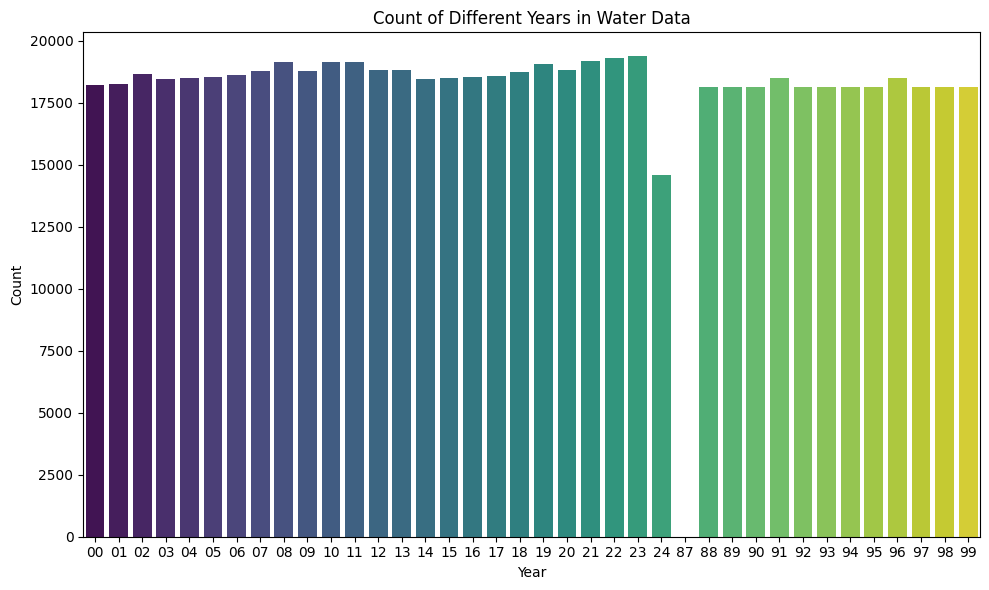

In [14]:
# Seaborn barplot to visualize the count of different years
plt.figure(figsize=(10, 6))
sns.barplot(x=year_counts.index, y=year_counts.values, hue=year_counts.index, palette='viridis', legend=False)
plt.title('Count of Different Years in Water Data')
plt.xlabel('Year')
plt.ylabel('Count')
plt.tight_layout()

### Dates Missing:

In [9]:
df = water_pd.copy()
df['date_difference'] = df.groupby('id')['date'].diff()
df['date_difference'].value_counts()

date_difference
7 days       683037
14 days           3
3444 days         1
56 days           1
1169 days         1
84 days           1
Name: count, dtype: int64

There are two main groups:
- Until 84 days of lack: they can be managed with a bbfill
- More than 1000 days lack: those cases need to be studied further, but they look like an imputation

In [10]:
df[df['date_difference'] > pd.Timedelta(days=7)]

,date,storage,id,date_difference
88523,2000-12-05,69.0,109,14 days
324956,2014-10-07,564.0,376,3444 days
347332,2003-05-20,0.0,396,14 days
347334,2003-07-15,0.0,396,56 days
347336,2006-10-03,22.0,396,1169 days
387709,2001-09-18,8.0,439,14 days
473362,1988-01-05,0.0,530,84 days


Now we have located which reservoirs have these lacks

In [ ]:
df['date_difference'].value_counts().index.sort_values()

TimedeltaIndex(['7 days', '14 days', '56 days', '84 days', '1169 days',
                '3444 days'],
               dtype='timedelta64[ns]', name='date_difference', freq=None)

In [55]:
mask = df['date_difference'].isin(df['date_difference'].value_counts().index.sort_values()[-2:])
df[mask]['id'].unique()

array([376, 396], dtype=int64)

So these are the two reservoirs that need to be studied further (376 and 396)

In [ ]:
def plot_reservoir(reservoir_id):
    df_reservoir = df_full[df_full['id'] == reservoir_id]
    plt.figure(figsize=(10, 5))
    plt.plot(df_reservoir['date'], df_reservoir['storage'], label='Water Level')
    plt.title(f'Reservoir {reservoir_id} Water Level Over Time')
    plt.xlabel('Date')
    plt.ylabel('Water Level')
    plt.legend()
    plt.show()

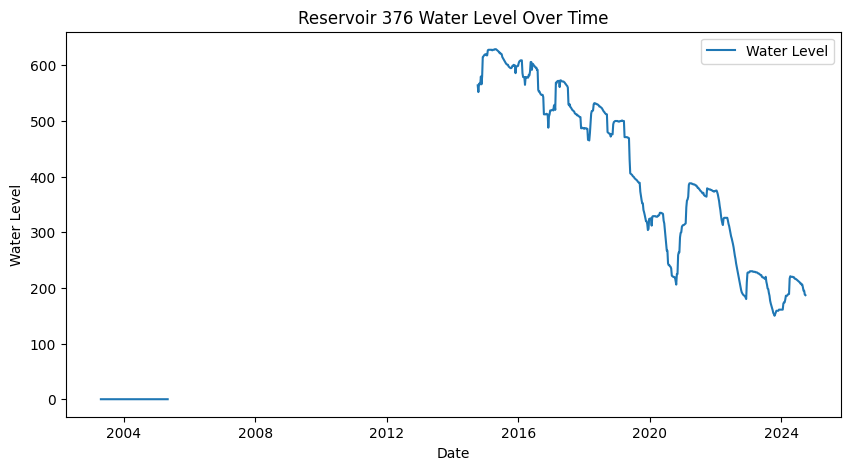

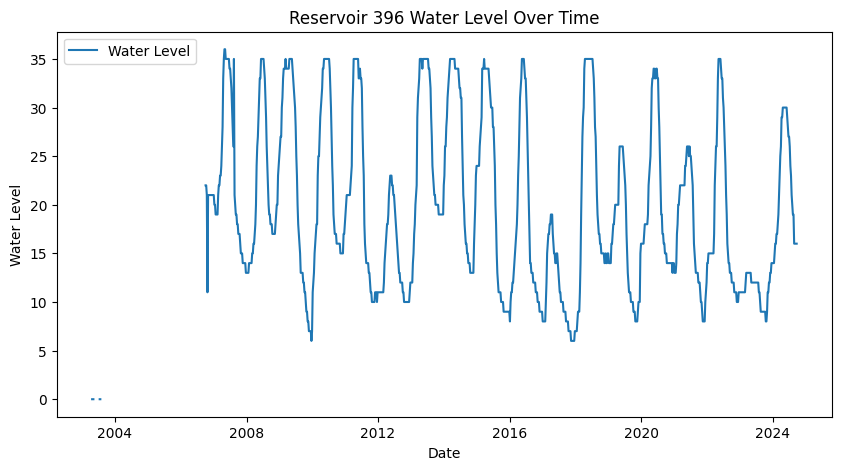

In [ ]:
for reservoir in df[mask]['id'].unique():
    plot_reservoir(reservoir)

They have a big gap because of certain outliers that will be removed, so that this gap doesn't exist anymore. These aren't the only reservoirs that don't start in 1988-01-05, as we can see in the next cell:

In [16]:
print(f"There are {df['id'].nunique()} reservoirs in the dataset.")
print(f"There are {df['date'].eq('1988-01-05').sum()} reservoirs that start in 1988-01-05.")


There are 401 reservoirs in the dataset.
There are 349 reservoirs that start in 1988-01-05.


### Studying median storage from all reservoirs per every week of the year

In [18]:
cleaned_water_path = PATHS['cleaned_data_notebooks'] / 'water_cleaned.parquet'
df = pd.read_parquet(cleaned_water_path)

In [19]:
df['week_idx'] = df['date'].dt.isocalendar().week
df

,date,storage,id,week_idx
0,1988-01-05,103,1,1
1,1988-01-12,103,1,2
2,1988-01-19,103,1,3
3,1988-01-26,103,1,4
4,1988-02-02,103,1,5
...,...,...,...,...
683340,2024-08-27,16,744,35
683341,2024-09-03,16,744,36
683342,2024-09-10,16,744,37
683343,2024-09-17,16,744,38


Barplot of the median storage from all reservoirs per every week of the year:

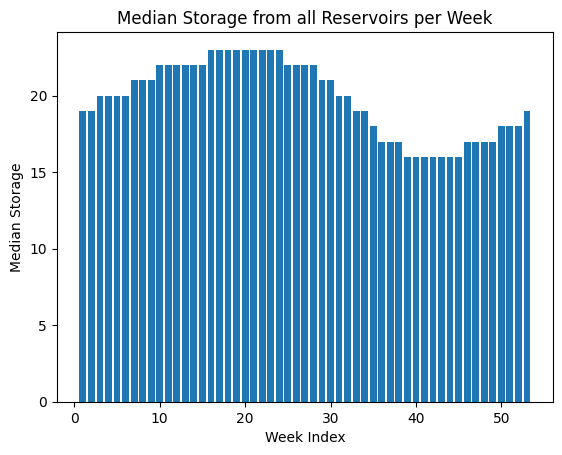

In [20]:
# Barplot of the median storage from all reservoirs per every week of the year

weekly_median = df.groupby('week_idx')['storage'].median()
plt.bar(weekly_median.index, weekly_median.values)
plt.xlabel('Week Index')
plt.ylabel('Median Storage')
plt.title('Median Storage from all Reservoirs per Week')
plt.show()

So it seems that there is a clear pattern in the data, with certain weeks showing consistently higher or lower median storage levels across all reservoirs

### Feature Engineering Proposal

- We have witnessed yearly seasonality, so apart from the current storage, we could also include multiples of 52-weeks lags
- The last years' storage levels are also essential for predicting next year's data, rather than the further ones (they will likely be taken apart)
- We could also explore interaction features, such as the combination of week index and year, to capture any potential trends over time
- Rolling statistics could be beneficial, such as the rolling mean or median over the last few weeks to smooth out short-term fluctuations and highlight longer-term trends
- It could be useful to try, instead of just storage, to use a feature that shows its ratio over the capacity, which is registered in reservoirs dataset